# Import Library

ในขั้นตอนนี้จะนำเข้าไลบรารีที่จำเป็นสำหรับการวิเคราะห์ข้อมูล
สร้างโมเดล Machine Learning และประเมินผลลัพธ์

In [486]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# Load Dataset

โหลดชุดข้อมูล Red Wine Quality จากไฟล์ CSV
เพื่อเตรียมข้อมูลสำหรับการวิเคราะห์และสร้างโมเดล

In [487]:
df = pd.read_csv("dataset.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# Dataset Overview

ตรวจสอบข้อมูลเบื้องต้นของชุดข้อมูล ได้แก่

- จำนวนข้อมูล
- ชนิดข้อมูล
- ค่าสถิติพื้นฐาน
- Missing Value

In [488]:
print("Shape :", df.shape)

print("\nInformation")
df.info()

print("\nMissing Value")
print(df.isnull().sum())

print("\nStatistics")
display(df.describe())

Shape : (1599, 12)

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

Missing Value
fixed acidity           0
volatile acidity        0
citric acid             0
r

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


# Data Exploration (EDA)

สำรวจการกระจายตัวของข้อมูลด้วย Histogram
เพื่อดูแนวโน้มของข้อมูลแต่ละตัวแปร

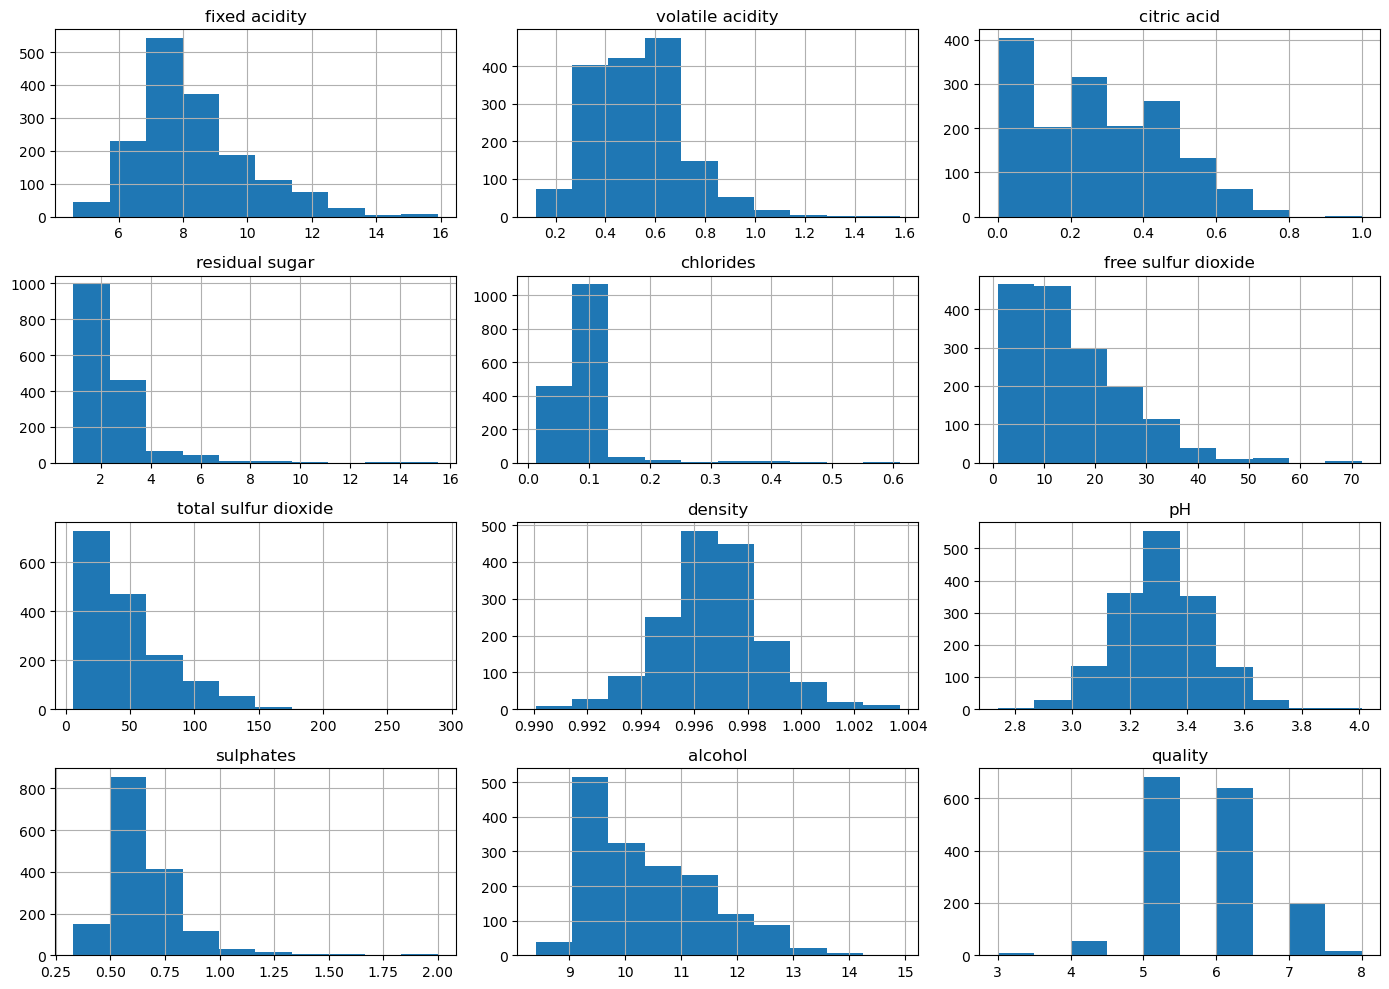

In [489]:
df.hist(figsize=(14,10))

plt.tight_layout()

plt.show()

# LAB 1 : Regression

Regression คือการทำนายค่าตัวเลข (Continuous Value)

ในตัวอย่างนี้จะทำนาย **Quality ของไวน์**
โดยเปรียบเทียบระหว่าง

- Simple Linear Regression
- Multiple Linear Regression

## Simple Linear Regression

ใช้ตัวแปรอิสระเพียง **1 ตัว**
คือ `alcohol`

เพื่อทำนายค่า `quality`

In [490]:
# Feature และ Target

X_simple = df[["alcohol"]]

y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X_simple,
    y,
    test_size=0.2,
    random_state=42
)

In [491]:
model_simple = LinearRegression()

model_simple.fit(X_train, y_train)

y_pred_simple = model_simple.predict(X_test)

## ประเมินผล Simple Linear Regression

ใช้ตัวชี้วัด

- MAE
- RMSE
- R² Score

In [492]:
mae = mean_absolute_error(y_test, y_pred_simple)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_simple))

r2 = r2_score(y_test, y_pred_simple)

print("Simple Linear Regression")
print("MAE :", round(mae,3))
print("RMSE :", round(rmse,3))
print("R² :", round(r2,3))

Simple Linear Regression
MAE : 0.575
RMSE : 0.707
R² : 0.236


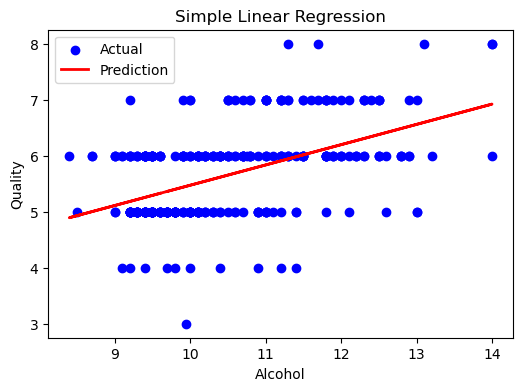

In [493]:
plt.figure(figsize=(6,4))

plt.scatter(
    X_test,
    y_test,
    color="blue",
    label="Actual"
)

plt.plot(
    X_test,
    y_pred_simple,
    color="red",
    linewidth=2,
    label="Prediction"
)

plt.xlabel("Alcohol")

plt.ylabel("Quality")

plt.title("Simple Linear Regression")

plt.legend()

plt.show()

# Multiple Linear Regression

ใช้ตัวแปรทุกคอลัมน์
(ยกเว้น Quality)

เพื่อเพิ่มความแม่นยำในการทำนาย

In [494]:
X = df.drop("quality", axis=1)

y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [495]:
model_multiple = LinearRegression()

model_multiple.fit(X_train, y_train)

y_pred_multiple = model_multiple.predict(X_test)

## ประเมินผล Multiple Linear Regression

เปรียบเทียบผลลัพธ์กับ
Simple Linear Regression

In [496]:
mae2 = mean_absolute_error(y_test, y_pred_multiple)

rmse2 = np.sqrt(mean_squared_error(y_test, y_pred_multiple))

r22 = r2_score(y_test, y_pred_multiple)

print("Multiple Linear Regression")
print("MAE :", round(mae2,3))
print("RMSE :", round(rmse2,3))
print("R² :", round(r22,3))

Multiple Linear Regression
MAE : 0.504
RMSE : 0.625
R² : 0.403


In [497]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_multiple
})

result.head()

,Actual,Predicted
0,6,5.346664
1,5,5.056313
2,6,5.664470
3,5,5.464515
4,6,5.725185


## เปรียบเทียบผล Regression

เปรียบเทียบค่า MAE, RMSE และ R²
ของทั้งสองโมเดล

In [498]:
compare = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "MAE": [
        mae,
        mae2
    ],
    "RMSE": [
        rmse,
        rmse2
    ],
    "R²": [
        r2,
        r22
    ]
})

compare

,Model,MAE,RMSE,R²
0,Simple Linear Regression,0.574966,0.706773,0.235618
1,Multiple Linear Regression,0.503530,0.624520,0.403180


# LAB 2 : Classification

Classification คือการจำแนกข้อมูลออกเป็นกลุ่ม

ในตัวอย่างนี้จะจำแนกคุณภาพไวน์เป็น

- Good Wine (1)
- Bad Wine (0)

โดยใช้ Logistic Regression

## Preparing Classification Data

สร้างคอลัมน์ใหม่ชื่อ `quality_label`

- Quality >= 6 = Good Wine (1)
- Quality < 6 = Bad Wine (0)

In [499]:
df["quality_label"] = (df["quality"] >= 6).astype(int)

df[["quality","quality_label"]].head()

,quality,quality_label
0,5,0
1,5,0
2,5,0
3,6,1
4,5,0


## Feature และ Target

เลือกตัวแปรสำหรับฝึกโมเดล

Target คือ quality_label

In [500]:
X = df.drop(["quality","quality_label"], axis=1)

y = df["quality_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Feature Scaling

ใช้ StandardScaler เพื่อปรับข้อมูลให้อยู่ในช่วงใกล้เคียงกัน

ช่วยให้โมเดลเรียนรู้ได้ดีขึ้น

In [501]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Principal Component Analysis (PCA)

ลดจำนวนคุณลักษณะให้เหลือ 2 มิติ

เพื่อใช้แสดงผลข้อมูลและ Decision Boundary

In [502]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

print(X_train_pca.shape)

(1279, 2)


## Logistic Regression

สร้างโมเดล Logistic Regression
เพื่อจำแนก Good Wine และ Bad Wine

In [503]:
model = LogisticRegression(random_state=42)

model.fit(X_train_pca, y_train)

y_pred = model.predict(X_test_pca)

## Accuracy

ตรวจสอบความถูกต้องของโมเดล

In [504]:
acc = accuracy_score(y_test, y_pred)

print("Accuracy :", round(acc,3))

Accuracy : 0.666


## Confusion Matrix

แสดงจำนวนข้อมูลที่ทำนายถูกและผิด

In [505]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 82  59]
 [ 48 131]]


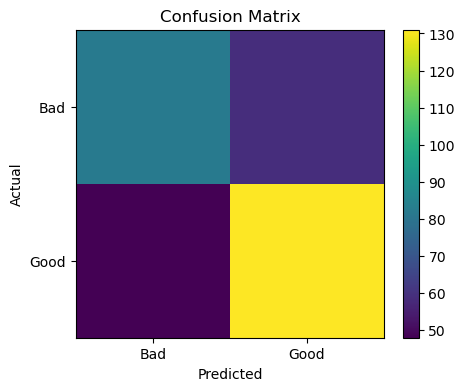

In [506]:
plt.figure(figsize=(5,4))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks([0,1],["Bad","Good"])

plt.yticks([0,1],["Bad","Good"])

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Classification Report

แสดงผลการประเมินโมเดล ได้แก่

- Precision
- Recall
- F1-score

In [507]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.58      0.61       141
           1       0.69      0.73      0.71       179

    accuracy                           0.67       320
   macro avg       0.66      0.66      0.66       320
weighted avg       0.66      0.67      0.66       320



## ROC Curve

ROC Curve ใช้ประเมินความสามารถในการจำแนกข้อมูลของโมเดล

ยิ่งค่า AUC เข้าใกล้ 1 ยิ่งแสดงว่าโมเดลมีประสิทธิภาพดี

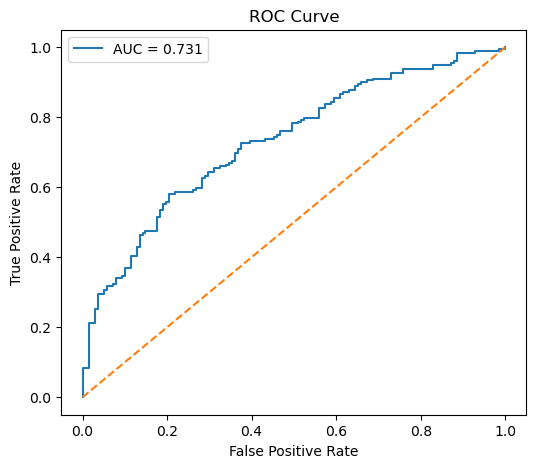

In [508]:
y_prob = model.predict_proba(X_test_pca)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

## Decision Boundary Visualization

แสดงการแบ่งพื้นที่การจำแนกข้อมูลของ Logistic Regression
บนข้อมูลที่ลดมิติด้วย PCA เหลือ 2 มิติ

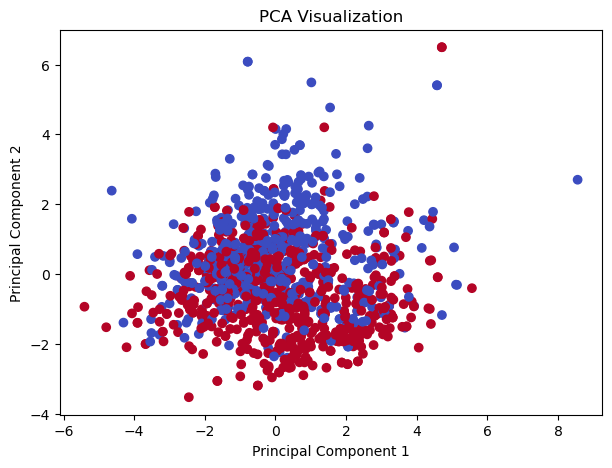

In [509]:
plt.figure(figsize=(7,5))

plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=y_train,
    cmap="coolwarm"
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("PCA Visualization")

plt.show()

# LAB 3 : Model Comparison

ในส่วนนี้จะเปรียบเทียบประสิทธิภาพของโมเดล Regression และ Classification

หัวข้อที่ศึกษา

- Simple vs Multiple Linear Regression
- Training vs Testing Performance
- Regression vs Classification
- Model Performance Metrics

## เปรียบเทียบ Simple และ Multiple Linear Regression

เปรียบเทียบค่า MAE, RMSE และ R²
เพื่อดูว่าโมเดลใดให้ผลการทำนายดีกว่า

In [510]:
comparison_regression = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "MAE": [
        mae,
        mae2
    ],
    "RMSE": [
        rmse,
        rmse2
    ],
    "R² Score": [
        r2,
        r22
    ]
})

comparison_regression

,Model,MAE,RMSE,R² Score
0,Simple Linear Regression,0.574966,0.706773,0.235618
1,Multiple Linear Regression,0.503530,0.624520,0.403180


## Training และ Testing Performance

เปรียบเทียบผลการทำนายของข้อมูล Train และ Test

หากค่าทั้งสองใกล้เคียงกัน
แสดงว่าโมเดลสามารถเรียนรู้ข้อมูลได้ดี

In [511]:
train_score = model_multiple.score(X_train, y_train)

test_score = model_multiple.score(X_test, y_test)

print("Training Score :", round(train_score,3))

print("Testing Score :", round(test_score,3))

Training Score : -104.077
Testing Score : -105.068


## Regression vs Classification

เปรียบเทียบตัวชี้วัดของทั้งสองโมเดล

Regression ใช้

- MAE
- RMSE
- R²

Classification ใช้

- Accuracy
- Precision
- Recall
- F1-score

In [512]:
print("Regression")

print("MAE :", round(mae2,3))

print("RMSE :", round(rmse2,3))

print("R² :", round(r22,3))

print("\nClassification")

print("Accuracy :", round(acc,3))

Regression
MAE : 0.504
RMSE : 0.625
R² : 0.403

Classification
Accuracy : 0.666


## Model Performance Metrics

สรุปผลการประเมินของแต่ละโมเดล

In [513]:
summary = pd.DataFrame({

    "Model":[
        "Simple Regression",
        "Multiple Regression",
        "Logistic Regression"
    ],

    "MAE":[
        round(mae,3),
        round(mae2,3),
        "-"
    ],

    "RMSE":[
        round(rmse,3),
        round(rmse2,3),
        "-"
    ],

    "R²":[
        round(r2,3),
        round(r22,3),
        "-"
    ],

    "Accuracy":[
        "-",
        "-",
        round(acc,3)
    ]

})

summary

,Model,MAE,RMSE,R²,Accuracy
0,Simple Regression,0.575,0.707,0.236,-
1,Multiple Regression,0.504,0.625,0.403,-
2,Logistic Regression,-,-,-,0.666


# สรุปผลการทดลอง

จากการทดลองพบว่า

- Multiple Linear Regression ให้ผลการทำนายคุณภาพไวน์แม่นยำกว่า Simple Linear Regression เนื่องจากใช้ข้อมูลจากหลายคุณลักษณะร่วมกัน
- Logistic Regression สามารถจำแนกไวน์เป็น Good Wine และ Bad Wine ได้อย่างมีประสิทธิภาพ
- การใช้ PCA ช่วยลดจำนวนคุณลักษณะและทำให้สามารถแสดงผลข้อมูลในรูปแบบ 2 มิติได้
- การประเมินผลด้วย MAE, RMSE, R² และ Accuracy ช่วยให้สามารถเปรียบเทียบประสิทธิภาพของโมเดลได้อย่างชัดเจน

# Conclusion

ในการทดลองครั้งนี้ได้ศึกษาการสร้างโมเดล Machine Learning ทั้ง Regression และ Classification โดยใช้ชุดข้อมูล Red Wine Quality จาก Kaggle

ผลการทดลองแสดงให้เห็นว่า Multiple Linear Regression มีประสิทธิภาพดีกว่า Simple Linear Regression สำหรับการทำนายคุณภาพไวน์ ส่วน Logistic Regression สามารถจำแนกคุณภาพไวน์ออกเป็น Good Wine และ Bad Wine ได้อย่างเหมาะสม

การเตรียมข้อมูล การปรับขนาดข้อมูล (Feature Scaling) และการใช้ PCA เป็นขั้นตอนที่ช่วยให้การสร้างโมเดลมีประสิทธิภาพมากขึ้น และสามารถนำความรู้ที่ได้ไปประยุกต์ใช้กับชุดข้อมูลอื่น ๆ ในงาน Machine Learning ได้